In [163]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import scipy.spatial as spatial
import scipy.cluster as clstr
from collections import defaultdict
import operator
from pathlib import Path

In [164]:
project_dir = Path.cwd().parent
print(project_dir)

c:\Users\feran\Projects\chessify


In [165]:
img = cv2.imread(project_dir / "training" / "testimg3.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

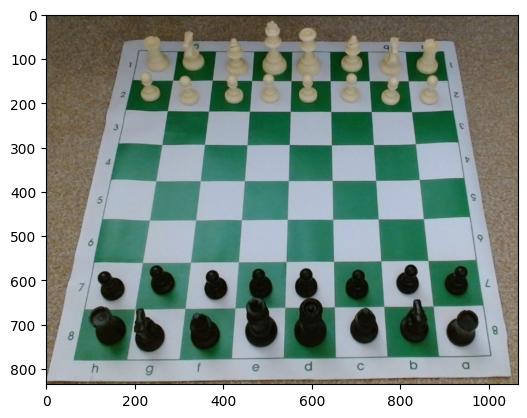

In [166]:
plt.imshow(img)

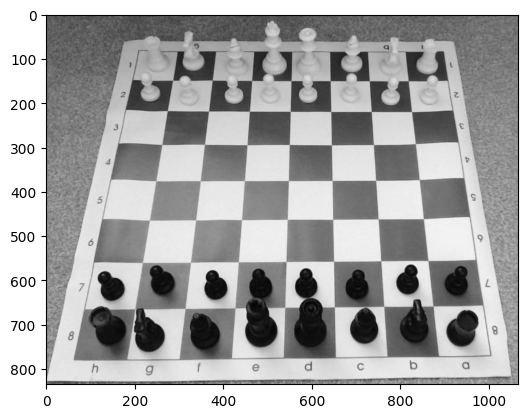

In [167]:
grey = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(grey, cmap = "grey")

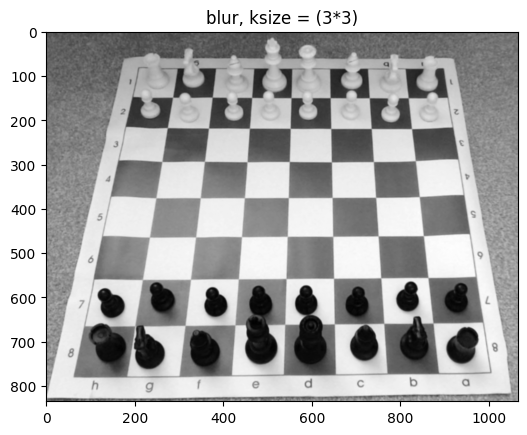

In [168]:
blur = cv2.blur(grey, (3, 3))
plt.title("blur, ksize = (3*3)")
plt.imshow(blur, cmap = "grey")

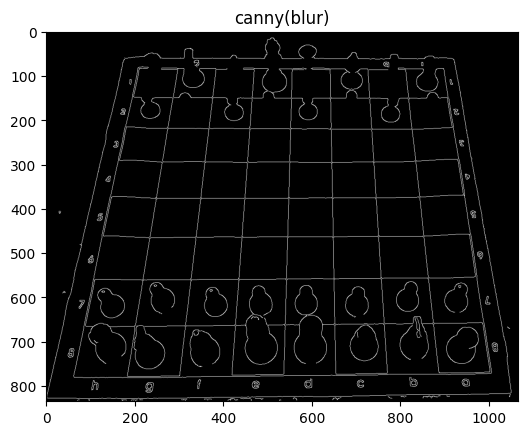

In [169]:
v = np.median(blur)
sigma = 0.33
l = int(max(0, (1.0 - sigma) * v))
u = int(min(255, (1.0 + sigma) * v))
canny = cv2.Canny(blur, l, u)
plt.title("canny(blur)")
plt.imshow(canny, cmap = "grey")

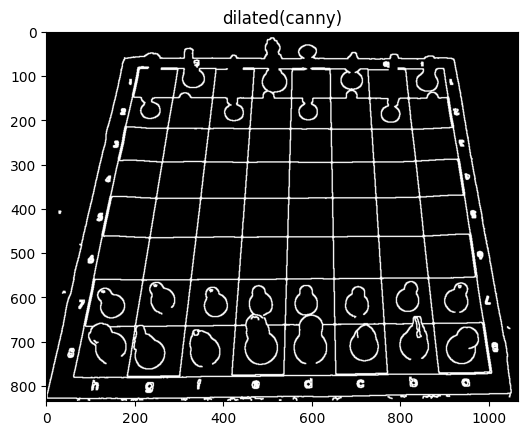

In [170]:
kernel = np.ones((3, 3), np.uint8)
dilated = cv2.dilate(canny, kernel, iterations = 1)
plt.title("dilated(canny)")
plt.imshow(dilated, cmap = "grey")

In [171]:
def drawHough(lines, image):
    for line in lines:
        rho = line[0][0]
        theta = line[0][1]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)    

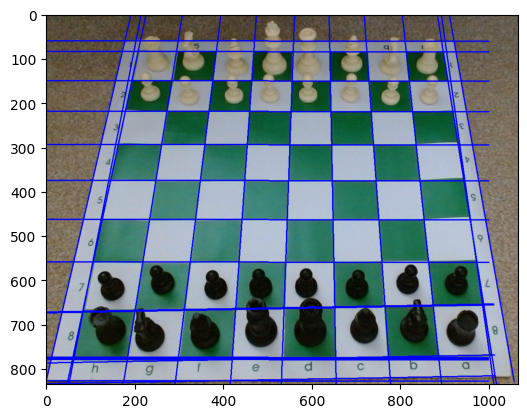

In [172]:
base = img.copy()
lines = cv2.HoughLines(dilated, 1, np.pi/180, 400)
drawHough(lines, base)
plt.imshow(base)

In [173]:
lines = np.reshape(lines, (-1, 2))
h = []
v = []
for rho, theta in lines:
    if theta < np.pi / 4 or theta > np.pi - np.pi/4:
        v.append([rho, theta])
    else:
        h.append([rho, theta])

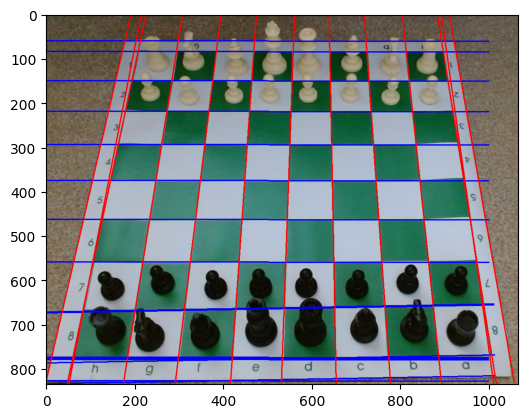

In [174]:
base = img.copy()
for line in h:
    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(base, (x1, y1), (x2, y2), (0, 0, 255), 2)
for line in v:
    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(base, (x1, y1), (x2, y2), (255, 0, 0), 2)
plt.imshow(base)

In [175]:
points = []
for rho_h, theta_h in h:
    for rho_v, theta_v in v:
        a = np.array([[np.cos(theta_h), np.sin(theta_h)], [np.cos(theta_v), np.sin(theta_v)]])
        b = np.array([rho_h, rho_v])
        intersect = np.linalg.solve(a, b)
        points.append(intersect)

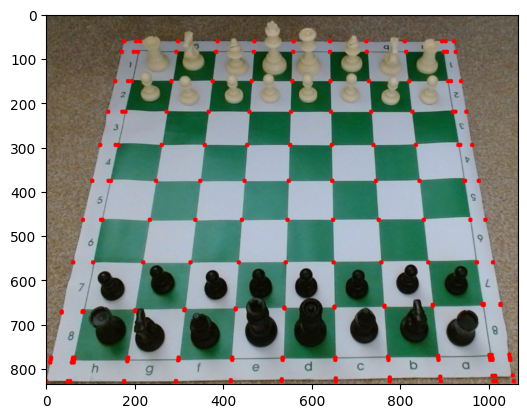

In [176]:
base = img.copy()
for point in points:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(base)

In [177]:
def cluster_intersections(points, max_dist=50):
    Y = spatial.distance.pdist(points)
    Z = clstr.hierarchy.single(Y)
    T = clstr.hierarchy.fcluster(Z, max_dist, "distance")
    clusters = defaultdict(list)
    for i in range(len(T)):
        clusters[T[i]].append(points[i])
    clusters = clusters.values()
    clusters = map(lambda arr: (np.mean(np.array(arr)[:, 0]), np.mean(np.array(arr)[:, 1])), clusters)
    result = []
    for point in clusters:
        result.append([point[0], point[1]])
    return result
    
points_clustered = cluster_intersections(points)

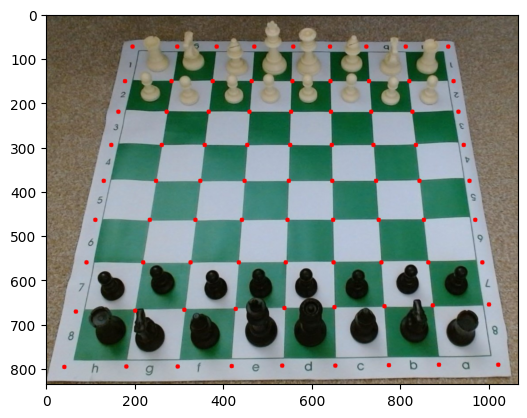

In [178]:
base = img.copy()
for point in points_clustered:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(base)

In [179]:
len(points_clustered)

81

In [180]:
def find_corners(points):
    #max x + y
    bottom_right, _ = max(enumerate([point[0] + point[1] for point in points]), key=operator.itemgetter(1))
    #min x + y
    top_left, _ = min(enumerate([point[0] + point[1] for point in points]), key=operator.itemgetter(1))
    #min x - y
    bottom_left, _ = min(enumerate([point[0] - point[1] for point in points]), key=operator.itemgetter(1))
    #max x - y
    top_right, _ = max(enumerate([point[0] - point[1] for point in points]), key=operator.itemgetter(1))
    return [points[bottom_right], points[top_left], points[bottom_left], points[top_right]]

corners = find_corners(points_clustered)

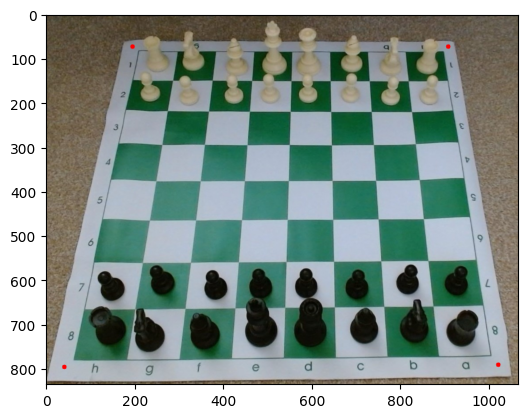

In [181]:
base = img.copy()
for point in corners:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(base)

In [182]:
def order_corners(pts: np.ndarray) -> np.ndarray:
    pts = np.asarray(pts)
    pts = pts.reshape((4, 2))
    rect = np.zeros((4, 1, 2), dtype = np.int32)

    s = pts.sum(axis = 1)
    rect[0] = pts[np.argmin(s)]
    rect[3] = pts[np.argmax(s)]

    diff = np.diff(pts, axis = 1)
    rect[1] = pts[np.argmin(diff)]
    rect[2] = pts[np.argmax(diff)]
    return np.float32(rect)

In [183]:
corners = order_corners(corners)
height, width = 640, 640
dimensions = np.float32([[0, 0],[width, 0], [0, height],[width, height]])
matrix = cv2.getPerspectiveTransform(corners, dimensions)
board = cv2.warpPerspective(img, matrix, (width, height))

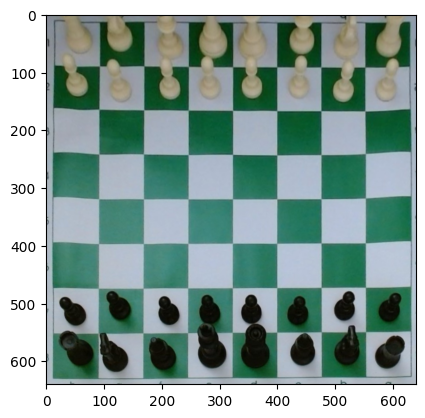

In [184]:
plt.imshow(board)

In [185]:
M = cv2.getPerspectiveTransform(corners, dimensions)
M_inv = cv2.invert(M)[1]

In [186]:
h, w, _ = board.shape
rows, cols = 8, 8

x_points = np.linspace(0, w, cols + 1, dtype=int)
y_points = np.linspace(0, h, rows + 1, dtype=int)
xv, yv = np.meshgrid(x_points, y_points)

grid_corners = []

for i in range(rows):
    for j in range(cols):
        top_left = (xv[i, j], yv[i, j])
        top_right = (xv[i, j + 1], yv[i, j])
        bottom_left = (xv[i + 1, j], yv[i + 1, j])
        bottom_right = (xv[i + 1, j + 1], yv[i + 1, j])

        
        corners = [top_left, top_right, bottom_left, bottom_right]
        grid_corners.append(corners)

grid_corners = np.array(grid_corners, dtype=np.float32).reshape(-1, 1, 2)
grid_corners = cv2.perspectiveTransform(grid_corners, M_inv)
grid_corners = grid_corners.reshape(-1, 4, 2)

In [187]:
len(grid_corners)

64

In [188]:
grid_corners[48]

array([[ 89.41394, 568.706  ],
       [202.05084, 568.3118 ],
       [ 66.29246, 677.25684],
       [183.99524, 676.7548 ]], dtype=float32)

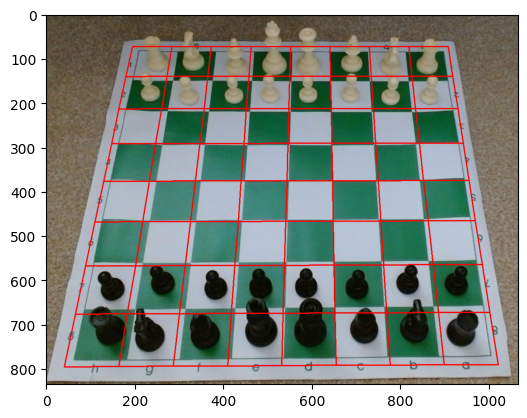

In [189]:
base = img.copy()
for square in grid_corners:
    top_left, top_right, bottom_left, bottom_right = square
    cv2.line(base, (int(top_left[0]), int(top_left[1])), (int(top_right[0]), int(top_right[1])), (255, 0, 0), 2)
    cv2.line(base, (int(top_right[0]), int(top_right[1])), (int(bottom_right[0]), int(bottom_right[1])), (255, 0, 0), 2)
    cv2.line(base, (int(bottom_right[0]), int(bottom_right[1])), (int(bottom_left[0]), int(bottom_left[1])), (255, 0, 0), 2)
    cv2.line(base, (int(bottom_left[0]), int(bottom_left[1])), (int(top_left[0]), int(top_left[1])), (255, 0, 0), 2)
plt.imshow(base)

In [190]:
squares = []
for square in grid_corners:
    x0, y0 = np.min(square, axis=0)
    x1, y1 = np.max(square, axis=0)
    squares.append((x0, y0, x1, y1))
print(squares[48])

(np.float32(66.29246), np.float32(568.3118), np.float32(202.05084), np.float32(677.25684))


In [191]:
squares_dict = {}
cols = "abcdefgh"
rows = "87654321"
square_names = [f'{col}{row}' for row in rows for col in cols]
print(square_names[48])

a2


In [192]:
for square, square_name in zip(squares, square_names):
    squares_dict[square_name] = {'piece': None, 'boundaries': np.array(square), 'score': None}

In [193]:
squares_dict['a2']

{'piece': None,
 'boundaries': array([ 66.29246, 568.3118 , 202.05084, 677.25684], dtype=float32),
 'score': None}

np.True_

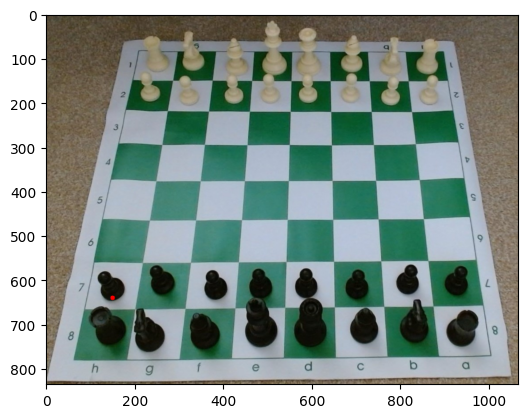

In [196]:
t = (150, 640)
base = img.copy()
cv2.circle(base, (int(t[0]), int(t[1])), 5, (255, 0, 0), -1)
plt.imshow(base)
squares_dict['a2']['boundaries'][0] < t[0] <= squares_dict['a2']['boundaries'][2] and squares_dict['a2']['boundaries'][1] < t[1] <= squares_dict['a2']['boundaries'][3]